This notebook shows all inputs needed for the calculation of the EBL,
and how to calculate the outputs.

Inputs for the EBL caused by the intrahalo light (Stars expelled from their galaxies):
- A_ihl
- alpha

# Imports

In [1]:
# Check that the working directory is correct for the paths
import os

if os.path.basename(os.getcwd()) == 'scripts' or os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir("..")

# If the directory for outputs is not present, create it.
if not os.path.exists("outputs/"):
    os.makedirs("outputs/")

In [2]:
import yaml
import psutil
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import astropy.units as u
import astropy.constants as c
from scipy.integrate import simpson
from scipy.interpolate import UnivariateSpline, RegularGridInterpolator

from ebl_codes.sfr_models import sfr_model
from ebl_codes.metall_models import metall_model
import ebl_codes.dust_absorption_models as dust_abs
from ebl_codes.EBL_class import EBL_model

# Data that I have but it is not mine so please request access?
from data.cb_measurs.import_cb_measurs import import_cb_data
from data.emissivity_measurs.emissivity_read_data import emissivity_data
from data.sfr_measurs.sfr_read import *
from data.metallicity_measurs.import_metall import import_met_data

# If we want to compare our results to previous calculations of the EBL, we load ebltable
# from https://github.com/me-manu/ebltable
from ebltable.ebl_from_model import EBL

Module hmf not loaded


### Some matplotlib values that I like for my graphs
Please feel free to change these (but I think they are cool)

In [3]:
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['axes.labelsize'] = 20
plt.rc('font', size=20)
plt.rc('axes', titlesize=20)
plt.rc('axes', labelsize=20)
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rc('legend', fontsize=18)
plt.rc('figure', titlesize=17)
plt.rc('xtick', top=True, direction='in')
plt.rc('ytick', right=True, direction='in')
plt.rc('xtick.major', size=7, width=1.5, top=True)
plt.rc('ytick.major', size=7, width=1.5, right=True)
plt.rc('xtick.minor', size=4, width=1)
plt.rc('ytick.minor', size=4, width=1)

In [4]:
# Some arrays to distinguish different models in the next plots
models = ['solid', 'dashed', 'dotted', 'dashdot']
colors = ['b', 'r', 'g', 'orange', 'grey', 'purple', 'k', 'cyan', 'brown']

linstyles_ssp = ['solid', '--', 'dotted', '-.']

markers = ['.', 'x', '+', '*', '^', '>', '<']
color_ssp = ['b', 'orange', 'k', 'r', 'green', 'grey', 'limegreen', 'purple', 'brown']

# Configuration file reading and data input/output

In [5]:
# Directory where we have the yaml file that has the inputs for our model
# If you want to save figures, it's very useful to use this directory to save them
# (i.e. plt.savefig(input_file_dir + NAME_FIG.pdf, bbox_inches='tight'))

input_file_dir = ('notebooks/')
# input_file_dir = ('scripts/input_files/')

In [6]:
# Configuration file reading and data input/output
def read_config_file(ConfigFile):
    with open(ConfigFile, 'r') as stream:
        try:
            parsed_yaml = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    return parsed_yaml

# We initialize the class with the input file
config_data = read_config_file(input_file_dir + 'input_example.yml')
# config_data = read_config_file(input_file_dir + 'input_dust_reem.yml')
ebl_class = EBL_model.input_yaml_data_into_class(config_data, log_prints=True)

2024-11-29 17:52:13 - INFO - 0.11s: Initialize cubes: end


### Details about config files
There is a problem that sometimes happens when inputting strings from yaml files. Sometimes the reader assumes that each character is to be read individually instead of as a string all together. If you ask for the length of the input, it counts each letter. Then, a parameter with the name `param_1: helloWorld` might recognize this as an array of individual characters, and asking
```
dict = {'param_1': helloWorld}
print(len(dict['param_1']))
 > 10 
```
The solution to this issue is to properly use [' '] in the config file sorrounding the string. That will cause python to always read it correctly. This almost never happens but when it does is kind of a nightmare. So beware.

## Inputs in the config file
List of inputs in the config file and its definitions.

First, general ones that need to appear for the correct funtioning of the code:

**COSMOLOGY CONSTANTS (flat LCDM assumed)**
```
cosmology_params:
  cosmo: [0.7, 0.3, 0.7] # [h_0, omega_matter, omega_L]
  omegaBar: 0.0453 # omega baryons of our model (this example = 0.0222/0.7**2.)
```
> These four parameters $h_0$, $\omega_{matter}$, $\omega_{\lambda}$ and $\omega_{baryons}$ are input in the class `FlatLambdaCDM` of `astropy.cosmology`. They can be changed, but beware because if you want to compare them to data: in order to calculate data, a cosmological model is assumed (for most observations). Altering the cosmological model might make it impossible (or wrong) to compare the output model with observational data.

**WAVELENGTH ARRAY FOR EBL [microns]**
```
wavelength_array:
  lfsteps: 700
  lmax: 1e5
  lmin: 1e-2
```
> Wavelength array where to calculate the EBL intensities and emissivities. They have to be given in microns. This example covers both the optical and infrared parts of the electromagnetic spectrum.

**REDSHIFT ARRAY FOR EBL**
```
redshift_array:
  zmin: 0.
  zmax: 10.0
  zsteps: 100
```
> This is the redshift array where the emissivities and EBL will be avaible as outputs. This does not denote the integration limit at high redshift. That one is given by the next parameter:
```
z_intmax: 40.0
```
> This is $z_{max}$ in Eq.(B1) in the paper based on this code, its physical meaning is the maximum reshift ar which the . I reccomend to not change this value.

**NUMBER OF INTEGRATION STEPS**
```
t_intsteps: 201
```
> Same as before, this number is appropiate for sampling the integral kernels.

**PRINT THE LOGS OF THE PROGRAM**

```
log_prints: True
```
> Finally, the possibility of having the program spit all the verbose or silently run. Change this parameter at any point in your program to decide whether you want detailed information about the processes happening or you would prefer the calculations to be silent.

# Stellar contribution to the EBL
We say stellar, but really any contribution that has luminosities tabulated can be input and calculate its EBL intensity.

For each of the models we have more inputs in the config file.

For and example of an SSP config file, we can have:
```
ssp_example:
    name: 'Our model'
    
    ssp:
        path_SSP: data/ssp_synthetic_spectra/starburst99/kroupa_padova/
        ssp_type: SB99
        file_name: /kroupa_
        ignore_rows: 6
        total_stellar_mass: 6
    
    dust_abs_models: finke2022
    dust_abs_params:
        params_ab18: [ 1.52, 0.35, 4.12, 5.89]
    
    metall_formula: 'lambda zz, args :10 ** (args[0] - args[1] * zz ** args[2]) * args[3]'
    metall_params:[ -0.147, 0.207, 0.819, 0.02]
    
    sfr_formula: 'lambda x, ci : ci[0] * (1 + x)**ci[1] / (1 + ((1+x)/ci[2])**ci[3])'
    sfr_params: [ 0.0150, 2.254, 3.347, 6.56]
    
    dust_reem: True
    dust_reem_params:
          library: chary2001
          file_path: 'data/ssp_synthetic_spectra/chary2001/chary_elbaz.fits'
          f_tir: 9.69
          wv_reem_min: 5.45  #[microns]
```
We are going to describe each of these in the next cells, explaining all the inputs that appear in this config example.

## SSP synthetic spectra - input for stellar EBL contribution
A simple stellar population (SSP) is defined as a group of stars born from the same gas cloud, which then evolve with no further star formation. The birth of the SSP lasts for megayears, so for cosmological purposes it can be assumed to be instantaneous. The stars in an SSP are assumed to share the same metallicity and age.

For this EBL calculation we input synthetic stellar spectra from SSPs. The spectra have to depend on wavelength, age of the population and (optionally) metallicity.

The way of inputting the stellar spectra is with our trustworthy config file. There are two available types of files accepted to input the populations. They are based on the filesystem of some scripts of synthetic spectra creation outputs. They are:
- Starburst99 (SB99) - simulations performed with the [Starburst99 code](https://massivestars.stsci.edu/starburst99/docs/default.htm).
- PopStar09 - simulations performed with the [PopStar code](https://www.fractal-es.com/PopStar/#ingredients).
- Generic (generic) - any kind of spectra, as long as they are correctly formatted (how to, explained below).

The parameters that can be present in the input file are:
```
ssp:
    path_ssp: data/ssp_synthetic_spectra/starburst99/kroupa_padova/
    ssp_type: SB99
    file_name: /kroupa_
    ignore_rows: 6
    total_stellar_mass: 6
    L_lambda: True
```
Not all the parameters are needed in all calculations, some depend on the type of input.

Depending on `ssp_type` different parameters are needed. For example, the type SB99 needs a normalization factor coming from the total initial mass of the population. The default value is $10^6 M_{\odot}$, so ```total_stellar_mass: 6 (dex)```. It also needs the ```file_name``` of the files. If you have the outputs from a SB99 simulation, you realize that each file has the name of the IMF used and the metallicity. We use the metallicity information, so we need to separate them.

There is another parameter: `ignore_rows: 6`. This allows to control whether the numerical data start in the first row of the file, or it would be necessary to jump some when reading in the file. In SB99 the typical jumping point are 6 rows, but generally if the files contain no other information this parameter can be set to 0.


The filesystem of the `generic` has to be precise in order to be correctly read and used. We want a directory, linked by `path_ssp`. In this directory we expect to find a number of files (one or more), each file name being the SSP metallicity of the data inside the file. The data format in each file is specific:
- The [0,0] entry is empty.
- The zeroth column [1:] contains the time/age of the SSP [years].
- The first row [1:] contains the wavelengths [Angstroms].
- The remaining values (n x m) are the luminosity $L_{\lambda}$ [erg/sec/A/Msun] or $L_{\nu}$ [erg/sec/Hz/Msun].
            
This method assumes that all files share the wavelength and age array. Since it is possible to input $L_{\lambda}$ or $L_{\nu}$, we have the parameter `L_lambda: True`, which is expected to be `True` with $L_{\lambda}$ and `False` with $L_{\nu}$ datasets. The realtion between these two is $\lambda L_{\lambda} = \nu L_{\nu}$.


A possible script to transform your data into a readable format by the code is:
```
import os
import numpy as np

input_dir = 'data/ssp_synthetic_spectra/pegase3/spectra_Kroupa/'

# A directory to store our spectra
output_dir = 'data/ssp_synthetic_spectra/pegase3/spectra_Kroupa_newformat/'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# We list all the files that we want to transform into the readable format
# (depending on the spectral library, other kind of loading might need to take place)
file_name = os.listdir(input_dir)
print(file_name)

for ind_file in file_name:
    data = np.loadtxt(input_dir + ind_file)

    # We want to name the new files with only the metallicity of each file,
    # this naming system will allow to read the filesystem automatically but
    # it needs a specific naming convention
    metall_string = ind_file.replace('.txt', '')
    metall_string = metall_string.replace('spectral_resultsZ', '')
    print(metall_string)

    # The name of each new file has to be only the metallicity of the stellar population
    file_out = open(output_dir + metall_string, 'w')

    wavelength_array = AAAAA  # WAVELENGTH ARRAY, HAS TO BE GIVEN IN MICRONS
    ages_array = AAAAA  # AGE ARRAY, HAS TO BE GIVEN IN YEARS

    len_wv = np.shape(wavelength_array)[0]
    len_age = np.shape(ages_array)[0]

    data_arr = np.zeros((len_wv + 1, len_age + 1))
    data_arr[1:, 0] = wavelength_array
    data_arr[0, 1:] = ages_array
    data_arr[1:, 1:] = AAAAA  # 2D ARRAY WITH LUMINOSITIES L_lambda, in units erg/s/Amstrong/M_sun

    np.savetxt(file_out, data_arr)
    file_out.close()
```



SSP model:  Pegase generic


2024-11-29 18:10:20 - INFO - 4.01s: Reading of SSP file



SSP model:  Our model


2024-11-29 18:10:22 - INFO - 1.35s: Reading of SSP file


Text(0, 0.5, 'log$_{10}$(L$_{\\lambda}$ [erg s$^{-1}$ $\\mathrm{\\AA}^{-1}$ M$_{\\odot}^{-1}$])')

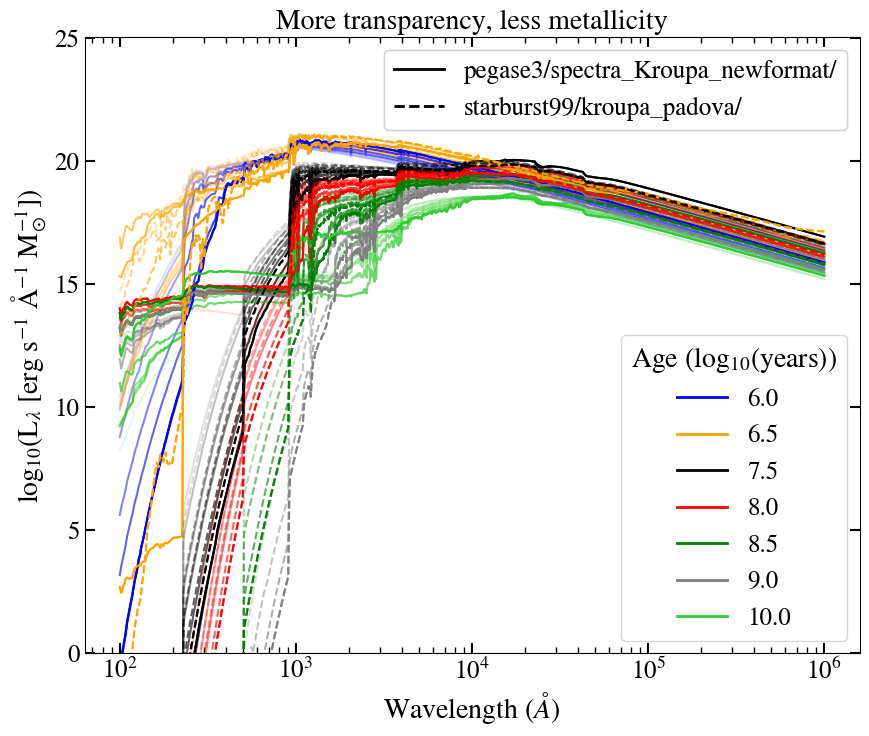

In [15]:
fig_ssp, ax_ssp = plt.subplots(figsize=(10, 8))

xx_amstrongs = np.logspace(2, 6, 2000)

previous_ssp = []
labels_ssp1 = []
handles_ssp1 = []
labels_ssp2 = []
handles_ssp2 = []

# Plot the synthetic spectra populations
for nkey, key in enumerate(config_data['ssp_models']):
    print()
    print('SSP model: ', config_data['ssp_models'][key]['name'])

    ssp_yaml = config_data['ssp_models'][key]['ssp']

    ebl_class.read_SSP_file(ssp_yaml)

    if ssp_yaml['path_ssp'] not in previous_ssp:
        previous_ssp.append(ssp_yaml['path_ssp'])
        labels_ssp2.append(ssp_yaml['path_ssp'].replace(
                'data/ssp_synthetic_spectra/', ''))
        handles_ssp2.append(
            plt.Line2D([], [], linewidth=2,
                       linestyle=linstyles_ssp[len(previous_ssp) - 1],
                       color='k'))
        
        list_met = ebl_class._ssp_metall
        list_met = np.sort(list_met)
        
        for n_met, met in enumerate(list_met):
            for i, age in enumerate([6.0, 6.5, 7.5, 8., 8.5, 9., 10.]):
                ax_ssp.plot(
                    xx_amstrongs, ebl_class.ssp_lumin_spline(
                        wv_array=xx_amstrongs, age_array=age, metall_array=met),
                    linestyle=linstyles_ssp[len(previous_ssp) - 1],
                    color=color_ssp[i],
                    alpha=float(n_met) / len(list_met) * 1.1
                )
                if n_met == 0 and len(previous_ssp) == 1:
                    labels_ssp1.append(age)
                    handles_ssp1.append(
                        plt.Line2D([], [], linewidth=2, linestyle='-',
                                   color=color_ssp[i]))

legend11 = plt.legend(handles_ssp1, labels_ssp1,
                      loc=4,
                      title=r'Age (log$_{10}$(years))')
legend22 = plt.legend(handles_ssp2, labels_ssp2,
                      loc=1,
                      )
ax_ssp.add_artist(legend11)
ax_ssp.add_artist(legend22)

plt.xscale('log')

plt.title('More transparency, less metallicity')

plt.ylim(bottom=0)

plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel(r'log$_{10}$(L$_{\lambda}$ '  # /Lsun '
           r'[erg s$^{-1}$ $\mathrm{\AA}^{-1}$ M$_{\odot}^{-1}$])')

## Dust absorption models
We provide some analytical models of dust absorption. Some of them give a wavelength dependence, other redshift one. Usually, they are combined into single model. The list of available dependencies is:

| Wavelength dependence | Model reference | Link |
| :-:  | :-:  | :-:  |
|$f_\mathrm{esc, dust}(\lambda) = 10^{-0.4\,A_{\lambda}}$ with $A_{\lambda} = 0.68 \cdot E(B-V) \cdot R \cdot (\lambda^{-1}-0.35)$ | kneiske2002 | [Paper](https://www.aanda.org/articles/aa/abs/2002/16/aa1647/aa1647.html) |
| razzaque2009 | razzaque2009 | [Paper](https://iopscience.iop.org/article/10.1088/0004-637X/697/1/483) |
| dust_att_finke | dust_att_finke | [Paper](https://iopscience.iop.org/article/10.3847/1538-4357/ac9843) |


| Redshift dependence | Model reference | Link |
| :-: | :-: | :-: |
| $f_\mathrm{esc, dust}(z) = 10^{-0.4\,A_{z}}$ with $A(z) = m_d \frac{(1 + z)^{n_d}}{1 + [(1+z)/p_d]^{q_d}}$ | abdollahi2018 | [Paper](https://www.science.org/doi/10.1126/science.aat8123) |


We also provide two combined cases:

| Name | Wavelength dependence | Redshift dependence |
| :-: | :-: | :-: |
| comb_model_1 | razzaque2009 | abdollahi2018 |
| finke2022 | dust_att_finke2 | abdollahi2018 |


The dependency is introduced with the input file, as before. The parameters are:
```
dust_abs_models: ['finke2022']
    dust_abs_params:
        params_ab18: [ 1.52, 0.35, 4.12, 5.89]
        fesc_steps_fn22: [0.188, 0.218, 0.293, 0.393, 0.857]
```

The first parameter `dust_abs_models` can be either a string or an array of strings, definining which models will be used for each part of the wavelegth and redshift dust absorption models. If no model is recognized the code will tell.

The parameters of each model can be separately chosen. The code tries to input the parameters for each model from the input file. If it cannot find them, the default parameters will be used and printed on the command line.
If given, the parameters have to follow the conventions:
| Model name | Parameter array name | Parameter order | Default parameters |
| :-: | :-: | :-: | :-: |
| kneiske2002 | params_kneiske2002 |[ $E(B-V)$, $R$ ] | [0.15, 3.2] |
| razzaque2009 | lambda_cuts_rz09 |   | [0.165, 0.220, 0.422] |
| razzaque2009 | initial_value_rz09 |   | [0.688, 0.151, 1.0, 0.728] |
| razzaque2009 | multipl_factor_rz09 |   | [0.556, -0.136, 1.148, 0.422] |
| dust_att_finke2 | lambda_steps_fn22 |$\lambda_i$, with $i=1,...,5$ | [0.15, 0.167, 0.218, 0.422, 2.] |
| dust_att_finke2 | fesc_steps_fn22 | $f_{\mathrm{esc, }i}$, with $i=1,...,5$ | [0.188, 0.218, 0.293, 0.393, 0.857] |
| abdollahi2018 | params_ab18 |[ $m_d$, $n_d$, $p_d$, $q_d$ ] | [1.49, 0.64, 3.4, 3.54] |

   -> Default parameters for lambda_steps_fn22 chosen:  [0.15, 0.167, 0.218, 0.422, 2.0]
   -> Default parameters for fesc_steps_fn22 chosen:  [0.188 0.218 0.293 0.393 0.857]
   -> Default parameters for lambda_steps_fn22 chosen:  [0.15, 0.167, 0.218, 0.422, 2.0]
   -> Default parameters for fesc_steps_fn22 chosen:  [0.188 0.218 0.293 0.393 0.857]
   -> Default parameters for lambda_steps_fn22 chosen:  [0.15, 0.167, 0.218, 0.422, 2.0]
   -> Default parameters for fesc_steps_fn22 chosen:  [0.188 0.218 0.293 0.393 0.857]
   -> Default parameters for lambda_steps_fn22 chosen:  [0.15, 0.167, 0.218, 0.422, 2.0]
   -> Default parameters for fesc_steps_fn22 chosen:  [0.188 0.218 0.293 0.393 0.857]
   -> Default parameter for Ebv, R chosen:  0.15 , 3.2
   -> Default parameters for params_ab18 chosen:  [1.49, 0.64, 3.4, 3.54]
   -> Default parameters for params_ab18 chosen:  [1.49, 0.64, 3.4, 3.54]
Example of no dust abs chosen:
   -> No dust absorption model chosen.
   -> CAREFUL: has the mode

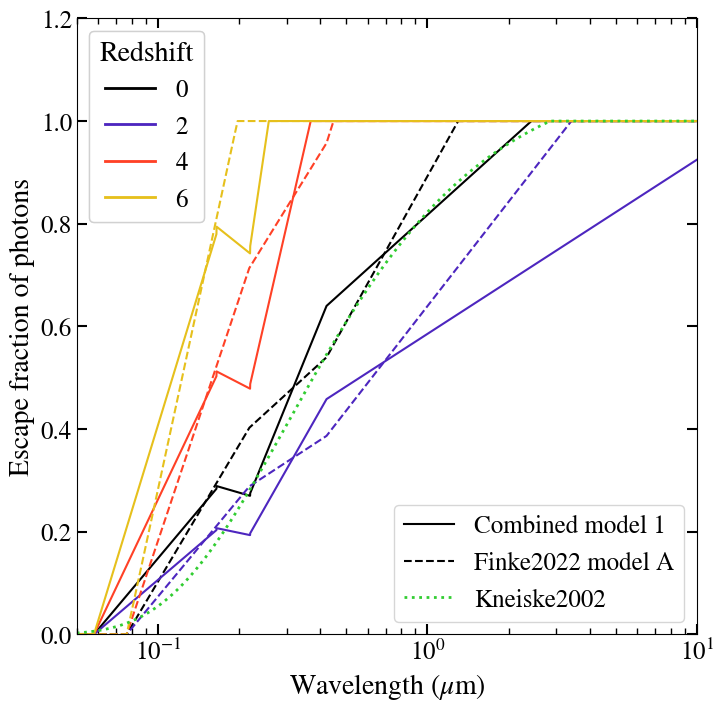

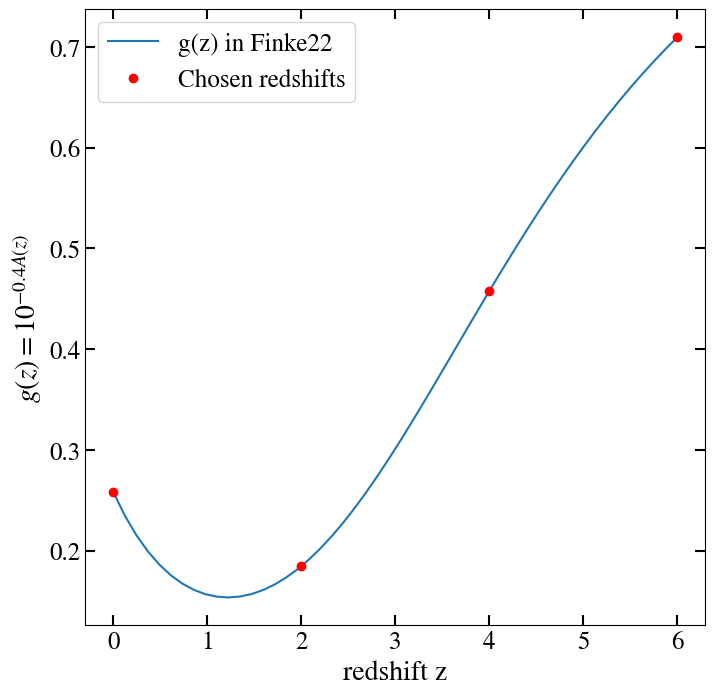

In [8]:
import os

if os.path.basename(os.getcwd()) == 'scripts' or os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir("..")
import ebl_codes.dust_absorption_models as dust_abs
import numpy as np
import matplotlib.pyplot as plt

x_lambda = np.logspace(-2, 1, num=5000)
# x_zetas = np.linspace(1e-6, 6, num=7)
x_zetas = np.array([0, 2, 4, 6])

fig, ax0 = plt.subplots(figsize=(8, 8))
color = []

for ni, ii in enumerate(x_zetas):
    if ni == 0:
        color.append( plt.cm.CMRmap(ni / float(len(x_zetas))))
        plt.plot(x_lambda, dust_abs.calculate_dust(x_lambda, z_array=x_zetas[ni], models=['comb_model_1']),
                 ls='-', c=color[ni], label='Combined model 1')
        plt.plot(x_lambda, dust_abs.calculate_dust(x_lambda, z_array=x_zetas[ni], models=['finke2022']),
                 ls='--', c=color[ni], label='Finke2022 model A')
    
    else:
        color.append( plt.cm.CMRmap(ni / float(len(x_zetas))))
        plt.plot(x_lambda, dust_abs.calculate_dust(x_lambda, z_array=x_zetas[ni], models=['comb_model_1']),
                 ls='-', c=color[ni])
        plt.plot(x_lambda, dust_abs.calculate_dust(x_lambda, z_array=x_zetas[ni], models=['finke2022']),
                 ls='--', c=color[ni])

plt.plot(x_lambda, 10 ** dust_abs.kneiske2002(x_lambda, dust_params=[]),
         'limegreen',label='Kneiske2002', ls=':', lw=2)


plt.ylabel('Escape fraction of photons')
plt.xlabel(r'Wavelength ($\mu$m)')

aa = plt.legend()
bb = plt.legend([plt.Line2D([], [], linewidth=2,
                       linestyle='-', color=color[i]) for i in range(len(x_zetas))],
                x_zetas, title='Redshift')
ax0.add_artist(aa)
ax0.add_artist(bb)

plt.xscale('log')

plt.ylim(0., 1.2)
plt.xlim(0.05, 10)

# ----------------------------------------------------------------------------
plt.figure(figsize=(8, 8))

aaa = np.linspace(0, 6)

plt.plot(aaa, 10 ** dust_abs.abdollahi2018(aaa), label='g(z) in Finke22')
plt.plot(x_zetas, 10 ** dust_abs.abdollahi2018(x_zetas), 'or', label='Chosen redshifts')
plt.legend()
plt.ylabel(r'$g(z) = 10^{-0.4 A(z)}$')
plt.xlabel('redshift z')

# Example of something that does not work
print('Example of no dust abs chosen:')
yyy = dust_abs.calculate_dust(x_lambda, 0, models=['aaa', 'abdollahi2018', 'aaa'])

## Metallicity evolution - input for stellar EBL contribution

| Model name | Formula | Reference parameters | Reference |
| :-: | :-: | :-: | :-: |
| tanikawa22 | $c_3 \times 10^{c_0 + c_1 \times z ^ {c_2}}$ |[ 0.153, 0.074, 1.34, 0.02] | [Eq. 4](https://iopscience.iop.org/article/10.3847/1538-4357/ac4247/pdf) |
| constant | $c_0$ |  0.02 | - |


SSP model:  Pegase generic
   -> Metallicity: default parameters chosen:  [0.153, 0.074, 1.34, 0.02]

SSP model:  Our model
   -> Metallicity: default parameters chosen:  [0.02]


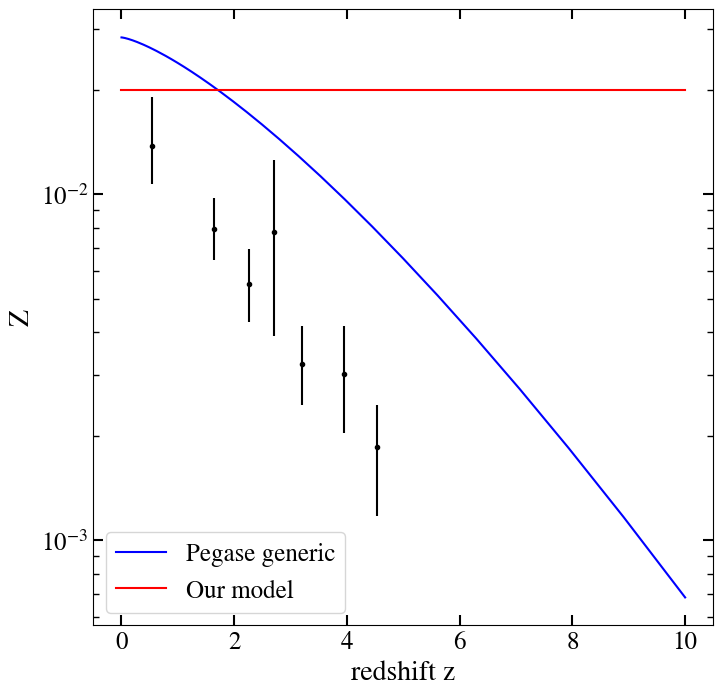

In [9]:
fig_met, ax_met = plt.subplots(figsize=(8, 8))

# We import the metallicity data (if available)
aa = import_met_data(ax=ax_met)

z_array = np.geomspace(1e-9, 10., num=200)
    
for nkey, key in enumerate(config_data['ssp_models']):
    print()
    print('SSP model: ', config_data['ssp_models'][key]['name'])

    ax_met.plot(z_array,
                metall_model(
                    zz_array=z_array,
                    metall_model=config_data['ssp_models'][key]['metall_formula']
                ),
                label=config_data['ssp_models'][key]['name'],
                color=colors[nkey % len(colors)])


# Figure specifications

plt.yscale('log')

plt.xlabel('redshift z')
plt.ylabel('Z')

ax_met.legend()

## Stellar formation rate - input for stellar EBL contribution
Enter the stellar formation rate ($\rho_\star$) as an input of the model for an SSP.

The code asks for a $\rho_\star$(z) with units M$_{\odot}$ / yr / Mpc$^{3}$.

There are two possible methods to input this dependency: with the definition in the config file, or giving a callable. Both of those methods are illustrated in the next cell.


| Model name | Formula | Reference parameters | Reference |
| :-: | :-: | :-: | :-: |
| abdollahi09 | $c_0 \frac{(1 + z) ^ {c_1}}
            {1 + \left((1 + z) / c_2\right) ^ {c_3}}$ |[ 0.153, 0.074, 1.34, 0.02] | [Eq. 4]() |
| sfr_finke22a | $c_0$ |  0.02 | - |
| sfr_cuba | $c_0$ |  0.02 | - |


SSP model:  Pegase generic
   -> SFR: default parameters chosen:  [0.015, 2.254, 3.347, 6.56]

SSP model:  Our model
   -> SFR: default parameters chosen:  [0.015, 2.254, 3.347, 6.56]


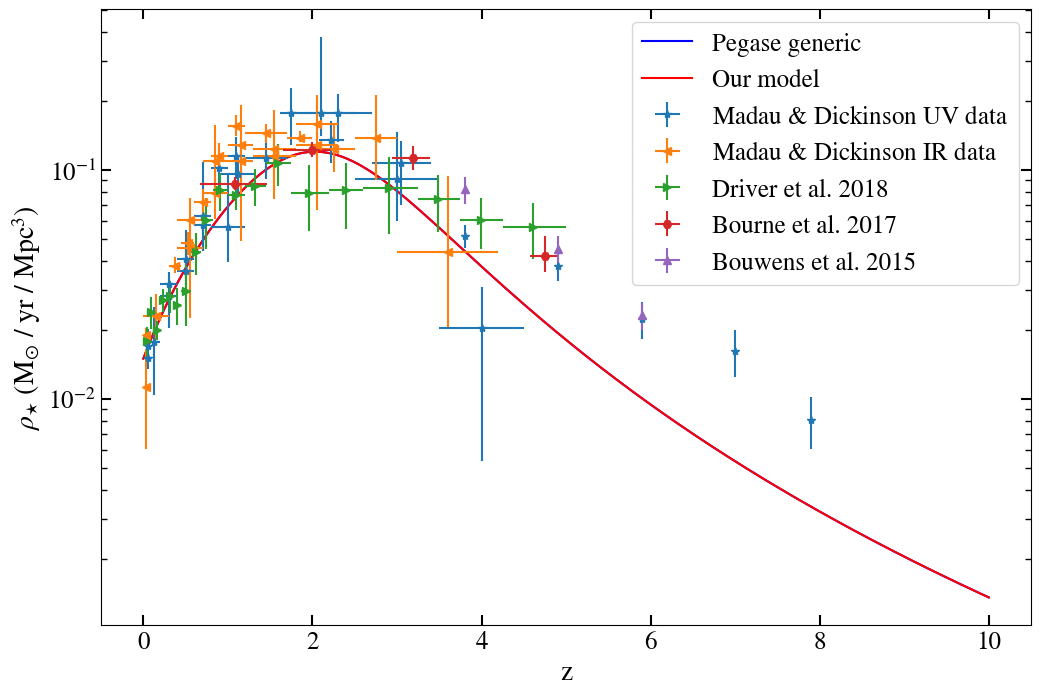

In [13]:
fig_sfr, ax_sfr = plt.subplots(figsize=(12, 8))

z_array = np.linspace(0., 10., num=500)

# We import the metallicity data from the Fermi compilation (if available)
sfr_data = sfr_data_dict()
plot_sfr_data(sfr_data)

for nkey, key in enumerate(config_data['ssp_models']):
    print()
    print('SSP model: ', config_data['ssp_models'][key]['name'])

    ax_sfr.plot(z_array, sfr_model(
        zz_array=z_array,
        sfr_model=config_data['ssp_models'][key]['sfr_formula']),
                label=config_data['ssp_models'][key]['name'],
                color=colors[nkey % len(colors)])


# Figure specifications

plt.yscale('log')

plt.ylabel(r'$\rho_{\star}$ (M$_{\odot}$ / yr / Mpc$^{3}$)')
plt.xlabel('z')

ax_sfr.legend()

## Dust reemission templates

This code uses dust reemisison templates to calculate the infrared part of the EBL. This requires external dust reemission templates, that we introduce here. We use and present two spectral libraries here:
- Chary2001
- BOSA

The templates get extrapolated, each of them in different ways.
- Wavelength: none of them get extrapolated at higher or smaller wavelengths.
- Metallicity: Chary2001 spectra do not have a dependency with metallicity, so they remain constant when changing this parameter. BOSA get extrapolated to higher and lower metallicities.
- $L_\mathrm{TIR}$: both templates get extrapolated at higher and lower $L_\mathrm{TIR}$.

### Using the dust reemission 
The EBL code initializes an spline that you can also use outside of the code, as:
```
dict = {'library': 'chary2001',
      'file_path': 'data/ssp_synthetic_spectra/chary2001/chary_elbaz.fits',
      'f_tir': 9.68,  # [dex]
      'wv_reem_min': 5.33 , # [microns]
         }
spline_dust_reem = ebl_class.spline_dust_reemission(dict)

# Usage example
print(10 ** spline_dust_reem(np.log10(wavelength[microns]), np.log10(L_tir[]), metallicity))
```
The inputs needed are 

(0.1, 300000.0)

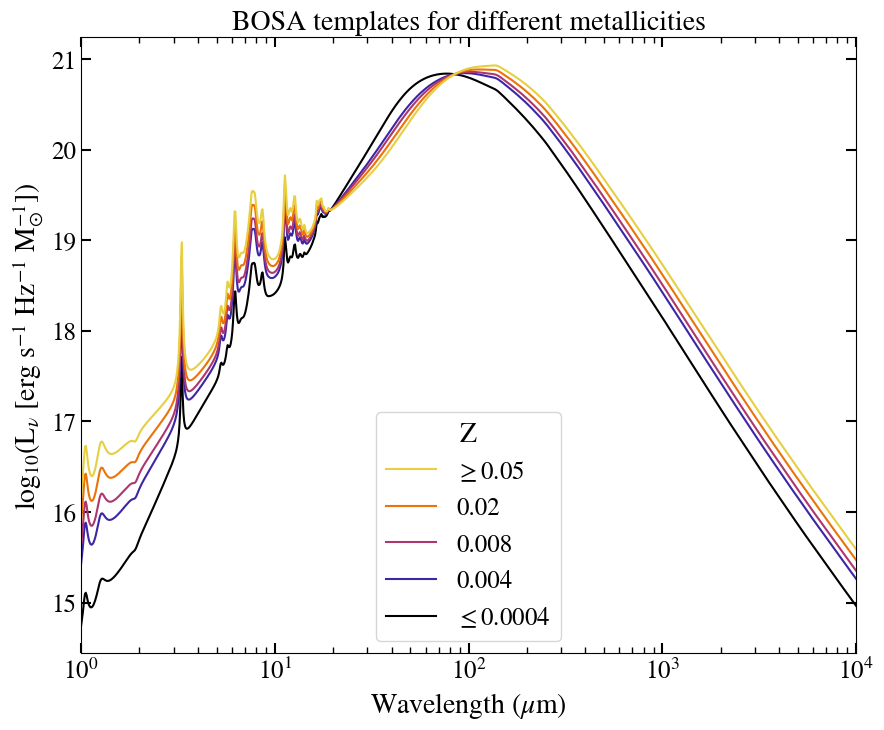

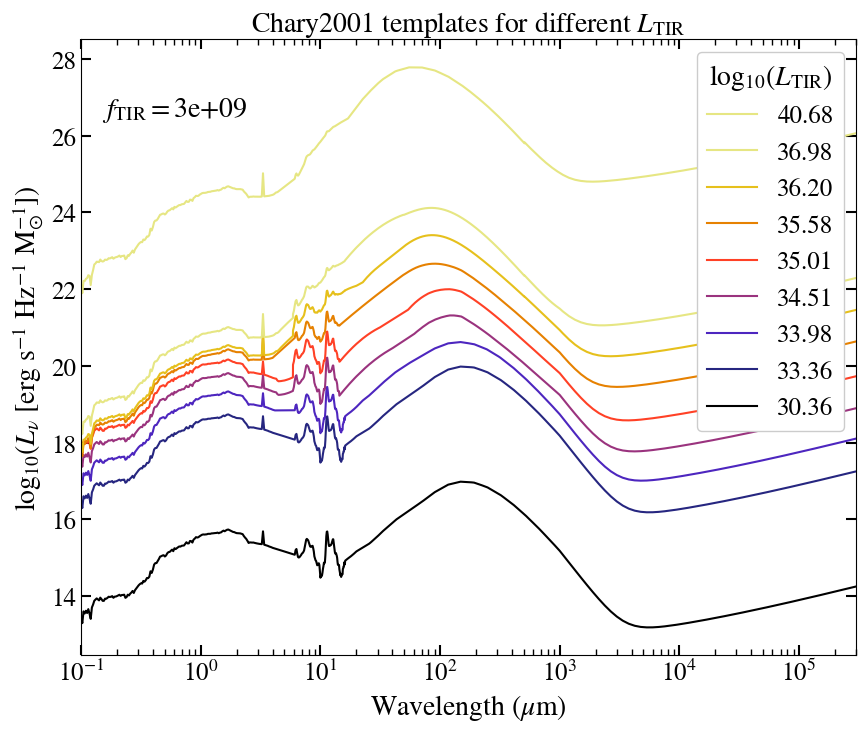

In [11]:
# Import the Chary2001 spectra

# We do need a normalization factor depending on the amount of stars in a typical galaxy
f_tir = 3e9

chary = fits.open('data/ssp_synthetic_spectra/chary2001/chary_elbaz.fits')

ir_wv = chary[1].data.field('LAMBDA')[0]
ir_freq = c.c.value / ir_wv * 1e6

ir_lum = (np.log10(chary[1].data.field('NULNUINLSUN')[0])
          - np.log10(f_tir))

aaa = np.zeros((np.shape(ir_lum)[0], np.shape(ir_lum)[1] + 2))
aaa[:, 1:-1] = ir_lum
aaa[:, 0] = ir_lum[:, 0] - 3.
aaa[:, -1] = ir_lum[:, -1] + 3.

ir_lum = aaa

# Cap the dust reemisison to the wavelength where there is
# proper reemission, not the whole possible spectrum
# ir_lum[ir_wv < 3.5, :] = 1e-43

l_tir = np.log(10) * simpson(
    10**ir_lum[::-1], x=np.log10(ir_freq)[::-1], axis=0)
l_tir *= c.L_sun.to(u.erg / u.s).value

sort_order = np.argsort(l_tir)

ir_lum -= np.log10(ir_freq[:, np.newaxis])
ir_lum += np.log10(c.L_sun.to(u.erg / u.s).value)
ir_lum[ir_lum < 1e-43] = 1e-43

l_tir = np.log10(l_tir)
# ----------------------------------------------------

data = fits.open('outputs/dust_reem/Z.fits')
aaa = data[1].data

yyy = np.column_stack((
    aaa['nuLnu[Z=6.99103]'], aaa['nuLnu[Z=6.99103]'],
    aaa['nuLnu[Z=7.99103]'],
    aaa['nuLnu[Z=8.29205999]'],
    aaa['nuLnu[Z=8.69]'],
    aaa['nuLnu[Z=9.08794001]'], aaa['nuLnu[Z=9.08794001]']))
yyy = (yyy * (c.L_sun.to(u.erg / u.s)).value
       * (aaa['wavelength'] * 1e-9 / c.c.value)[:, np.newaxis]
       )

yyy = np.log10(yyy)

# ---------------------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.title('BOSA templates for different metallicities')

metalls = [6.99103, 7.99103, 8.29205999, 8.69, 9.08794001]
metalls_Ztot = 10**(np.array(metalls) - 12)/4.89778819e-04*0.02
metalls_Ztot = [r'$\leq$'+str(0.0004), 0.004,  0.008,  0.02,
                r'$\geq$'+str(0.05)]

for iii in range(len(metalls)):
    plt.plot(aaa['wavelength']*1e-3, yyy[:, iii+1],
             label=metalls_Ztot[iii],
             c=plt.cm.CMRmap(iii / len(metalls_Ztot)))


handles, labels = plt.gca().get_legend_handles_labels()
order = np.arange(len(handles)-1, -1, -1, dtype=int)
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], title='Z')


plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel(r'log$_{10}$(L$_{\nu}$ '  # /Lsun '
           r'[erg s$^{-1}$ $\mathrm{Hz}^{-1}$ M$_{\odot}^{-1}$])')

plt.xscale('log')
# plt.yscale('log')

plt.xlim(1, 1e4)
# plt.ylim(16, 25.5)

plt.savefig('outputs/dust_reem/bosaZ_plot.pdf',
            bbox_inches='tight')
plt.savefig('outputs/dust_reem/bosaZ_plot.png',
            bbox_inches='tight')
# ---------------------------------------------------------------------

plt.figure(figsize=(10, 8))
plt.title(r'Chary2001 templates for different $L_\mathrm{TIR}$')

plt.plot(ir_wv, ir_lum[:, 0],
         label=r'%.2f' % l_tir[0], c=plt.cm.CMRmap(0/8.))
for ni, i in enumerate(range(1, np.shape(ir_lum)[1]-1, 15)):
    plt.plot(ir_wv, ir_lum[:, i],
             label='%.2f' % l_tir[i],
             c=plt.cm.CMRmap((ni+1) / 8.)
             )
plt.plot(ir_wv, ir_lum[:, -1],
         label=r'%.2f' % l_tir[-1], c=plt.cm.CMRmap(7/8.))

plt.text(x=0.15, y=26.5, s=r'$f_\mathrm{TIR} = $%.0e' %f_tir)

plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel(r'log$_{10}(L_{\nu}$ '  # /Lsun '
           r'[erg s$^{-1}$ $\mathrm{Hz}^{-1}$ M$_{\odot}^{-1}$])')

handles, labels = plt.gca().get_legend_handles_labels()
order = np.arange(len(handles)-1, -1, -1, dtype=int)
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],
           ncol=1, loc=1, title=r'log$_{10}\left(L_\mathrm{TIR}\right)$',
           framealpha=1)

plt.xscale('log')

plt.xlim(0.1, 3e5)
# plt.ylim(16, 25.5)

# Intrahalo light and its contribution to the EBL
